In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('Hospitalisations-for-intentional-self-harm-2023-24_National-Hospital-Morbidity-Database.xlsx', sheet_name='NHMD S3', header=1)

In [3]:
df.head()

,Mechanism,Sex,Age group,Measure,2008–09,2009–10,2010–11,2011–12,2012–13,2013–14,2014–15,2015–16,2016–17,2017–18,2018–19,2019–20,2020–21,2021–22,2022–23,2023–24
0,"X60 nonopioid analgesics, antipyretics and ant...",Males,0–24,Number,425,497,470,534,568,471,531,650,713,643,548,508,631,537,490,455
1,"X60 nonopioid analgesics, antipyretics and ant...",Males,0–24,"Rate (per 100,000)",11.6,13.38,12.58,14.18,14.89,12.2,13.61,16.48,17.86,15.92,13.44,12.41,15.52,13.22,11.85,10.87
2,"X60 nonopioid analgesics, antipyretics and ant...",Males,0–24,Per cent,19.12,21.34,19.37,21.79,22.08,20.24,20.56,22.44,22.63,22.44,18.83,16.98,20.87,20.71,21.78,21.21
3,"X61 antiepileptic, sedative-hypnotic, antipark...",Males,0–24,Number,795,810,880,835,907,860,879,1044,1100,988,1056,1179,1048,904,730,688
4,"X61 antiepileptic, sedative-hypnotic, antipark...",Males,0–24,"Rate (per 100,000)",21.69,21.81,23.56,22.17,23.78,22.28,22.54,26.47,27.55,24.47,25.89,28.8,25.78,22.25,17.65,16.44


In [4]:
df.columns

Index(['Mechanism ', 'Sex', 'Age group', 'Measure', '2008–09', '2009–10',
       '2010–11', '2011–12', '2012–13', '2013–14', '2014–15', '2015–16',
       '2016–17', '2017–18', '2018–19', '2019–20', '2020–21', '2021–22',
       '2022–23', '2023–24'],
      dtype='object')

In [6]:
# Import the libraries we need
# pandas = working with data tables
# matplotlib = drawing charts
# openpyxl = reading Excel files

import pandas as pd
import matplotlib.pyplot as plt

# Load the S3 sheet — this is the mechanism breakdown
df = pd.read_excel('Hospitalisations-for-intentional-self-harm-2023-24_National-Hospital-Morbidity-Database.xlsx',
                   sheet_name='NHMD S3',
                   header=1)  # row index 1 is the actual column header row

# Preview the raw data
df.head(10)

,Mechanism,Sex,Age group,Measure,2008–09,2009–10,2010–11,2011–12,2012–13,2013–14,2014–15,2015–16,2016–17,2017–18,2018–19,2019–20,2020–21,2021–22,2022–23,2023–24
0,"X60 nonopioid analgesics, antipyretics and ant...",Males,0–24,Number,425,497,470,534,568,471,531,650,713,643,548,508,631,537,490,455
1,"X60 nonopioid analgesics, antipyretics and ant...",Males,0–24,"Rate (per 100,000)",11.6,13.38,12.58,14.18,14.89,12.2,13.61,16.48,17.86,15.92,13.44,12.41,15.52,13.22,11.85,10.87
2,"X60 nonopioid analgesics, antipyretics and ant...",Males,0–24,Per cent,19.12,21.34,19.37,21.79,22.08,20.24,20.56,22.44,22.63,22.44,18.83,16.98,20.87,20.71,21.78,21.21
3,"X61 antiepileptic, sedative-hypnotic, antipark...",Males,0–24,Number,795,810,880,835,907,860,879,1044,1100,988,1056,1179,1048,904,730,688
4,"X61 antiepileptic, sedative-hypnotic, antipark...",Males,0–24,"Rate (per 100,000)",21.69,21.81,23.56,22.17,23.78,22.28,22.54,26.47,27.55,24.47,25.89,28.8,25.78,22.25,17.65,16.44
5,"X61 antiepileptic, sedative-hypnotic, antipark...",Males,0–24,Per cent,35.76,34.78,36.26,34.07,35.26,36.96,34.03,36.05,34.91,34.49,36.28,39.41,34.66,34.86,32.44,32.07
6,X62 narcotics and psychodysleptics [hallucinog...,Males,0–24,Number,74,84,65,95,110,86,130,125,132,127,118,138,141,96,77,85
7,X62 narcotics and psychodysleptics [hallucinog...,Males,0–24,"Rate (per 100,000)",2.02,2.26,1.74,2.52,2.88,2.23,3.33,3.17,3.31,3.14,2.89,3.37,3.47,2.36,1.86,2.03
8,X62 narcotics and psychodysleptics [hallucinog...,Males,0–24,Per cent,3.33,3.61,2.68,3.88,4.28,3.7,5.03,4.32,4.19,4.43,4.05,4.61,4.66,3.7,3.42,3.96
9,Other drugs (X63 X64),Males,0–24,Number,134,150,152,199,171,158,190,229,244,237,256,253,270,243,250,287


In [5]:
len(df)

510

In [9]:
# Define the year columns we want to keep
year_cols = ['2008–09','2009–10','2010–11','2011–12','2012–13','2013–14',
             '2014–15','2015–16','2016–17','2017–18','2018–19','2019–20',
             '2020–21','2021–22','2022–23','2023–24']

# Rename the first column cleanly
df.rename(columns={df.columns[0]: 'Mechanism'}, inplace=True)

# Convert Mechanism column to string first so .str methods work safely
df['Mechanism'] = df['Mechanism'].astype(str)

# Filter to only the rows we want
df_clean = df[
    (df['Sex'] == 'Persons') &
    (df['Age group'] == 'Total') &
    (df['Measure'] == 'Number') &
    (~df['Mechanism'].str.startswith(' ')) &  # removes footnote rows
    (df['Mechanism'] != 'nan')                # removes empty rows
].copy()

# Keep only mechanism name and year columns
df_clean = df_clean[['Mechanism'] + year_cols]

# Reset the index so it starts from 0
df_clean = df_clean.reset_index(drop=True)

# Preview
df_clean

,Mechanism,2008–09,2009–10,2010–11,2011–12,2012–13,2013–14,2014–15,2015–16,2016–17,2017–18,2018–19,2019–20,2020–21,2021–22,2022–23,2023–24
0,"X60 nonopioid analgesics, antipyretics and ant...",4680,4958,4867,5287,5751,5449,5635,6533,7215,6129,5738,5378,6618,5944,5416,4851
1,"X61 antiepileptic, sedative-hypnotic, antipark...",12212,12187,11959,12388,11885,11633,12256,13456,13818,12417,12298,12020,11840,10409,9153,8723
2,X62 narcotics and psychodysleptics [hallucinog...,1183,1352,1339,1454,1556,1607,1764,2036,2125,1895,1938,1690,1553,1334,1267,1255
3,Other drugs (X63 X64),1827,1942,1994,2088,2123,2097,2229,2602,2903,2642,2873,3002,2989,2798,2915,3409
4,Alcohol (X65),318,361,315,343,320,293,310,382,349,353,348,372,359,314,260,217
5,"Other chemical (excl gas) (X66, X68 X69)",497,570,541,574,575,589,619,749,698,611,633,603,631,543,541,567
6,Gas (X67),359,317,314,317,289,243,276,290,289,192,209,164,166,126,152,114
7,Hanging (X70),557,544,581,693,659,659,759,785,873,782,817,838,821,776,726,708
8,Sharp Objects (X78),3255,3334,3378,3253,3192,3089,3389,3501,3799,3547,3580,3433,3774,3526,3286,3248
9,"Other cause (X71-X77,X79,X80-X84,Y87.0)",732,760,765,716,753,726,880,937,1064,918,1000,1143,1135,1096,1049,982


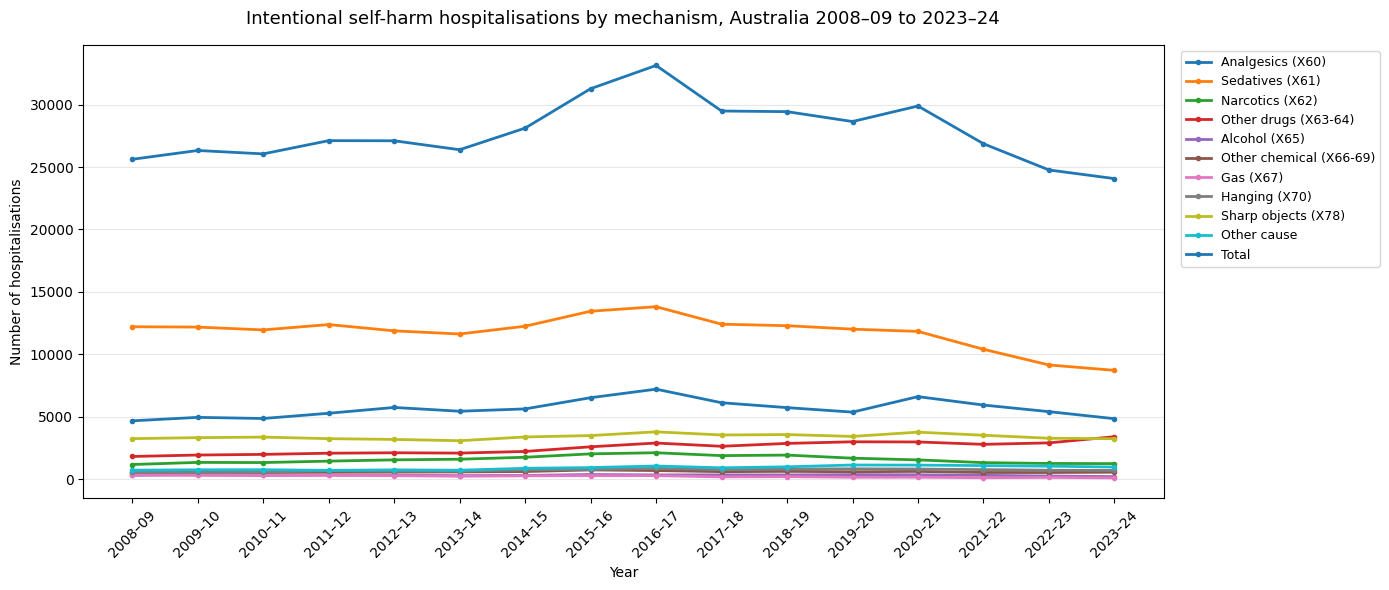

Chart saved!


In [10]:
# Transpose the data so years become rows — easier for plotting
df_plot = df_clean.set_index('Mechanism').T

# Shorten mechanism names so they fit on the chart legend
short_names = {
    'X60 nonopioid analgesics, antipyretics and antirheumatics': 'Analgesics (X60)',
    'X61 antiepileptic, sedative-hypnotic, antiparkinsonism and psychotropic drugs, not elsewhere classified': 'Sedatives (X61)',
    'X62 narcotics and psychodysleptics [hallucinogens], not elsewhere classified': 'Narcotics (X62)',
    'Other drugs (X63 X64)': 'Other drugs (X63-64)',
    'Alcohol (X65)': 'Alcohol (X65)',
    'Other chemical (excl gas) (X66, X68 X69)': 'Other chemical (X66-69)',
    'Gas (X67)': 'Gas (X67)',
    'Hanging (X70)': 'Hanging (X70)',
    'Sharp Objects (X78)': 'Sharp objects (X78)',
    'Other cause (X71-X77,X79,X80-X84,Y87.0)': 'Other cause'
}
df_plot.rename(columns=short_names, inplace=True)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

for col in df_plot.columns:
    ax.plot(df_plot.index, df_plot[col], marker='o', markersize=3, linewidth=2, label=col)

ax.set_title('Intentional self-harm hospitalisations by mechanism, Australia 2008–09 to 2023–24',
             fontsize=13, pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Number of hospitalisations')
ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart1_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

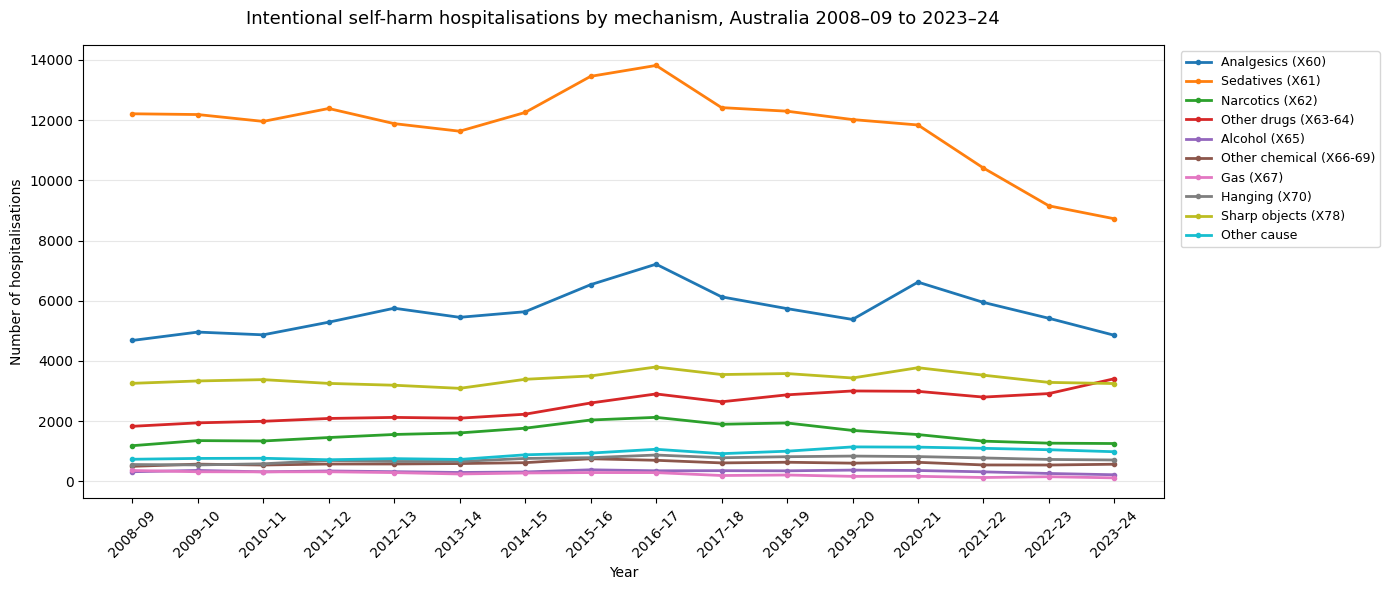

In [11]:
# Remove the Total row — it's a sum, not a mechanism
df_clean = df_clean[df_clean['Mechanism'] != 'Total']
df_clean = df_clean.reset_index(drop=True)

# Replot with the fix
df_plot = df_clean.set_index('Mechanism').T
df_plot.rename(columns=short_names, inplace=True)

fig, ax = plt.subplots(figsize=(14, 6))

for col in df_plot.columns:
    ax.plot(df_plot.index, df_plot[col], marker='o', markersize=3, linewidth=2, label=col)

ax.set_title('Intentional self-harm hospitalisations by mechanism, Australia 2008–09 to 2023–24',
             fontsize=13, pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Number of hospitalisations')
ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart1_trends.png', dpi=150, bbox_inches='tight')
plt.show()

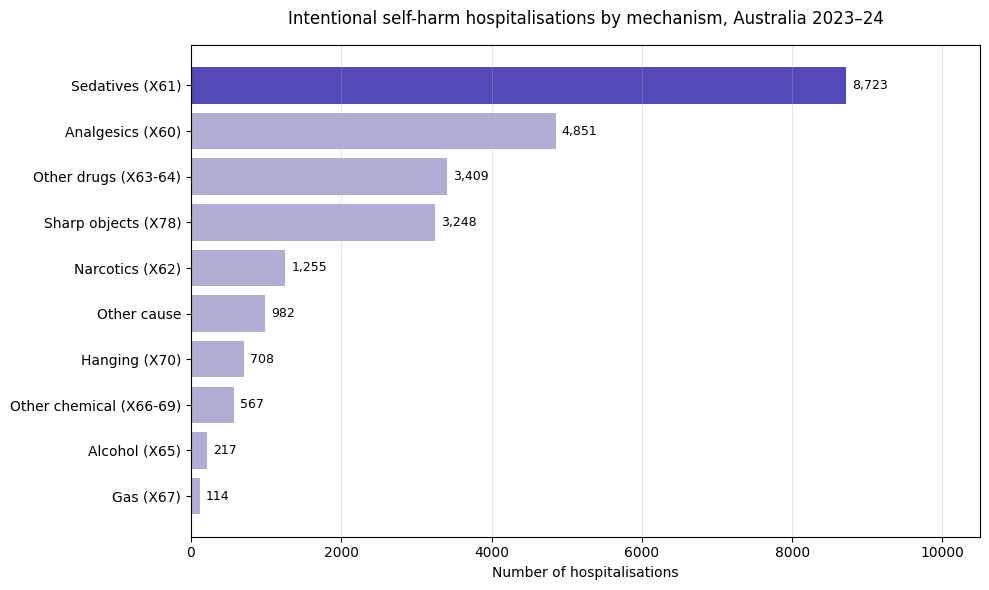

In [12]:
# Get 2023-24 values and sort from highest to lowest
latest = df_clean[['Mechanism', '2023–24']].copy()
latest.columns = ['Mechanism', 'Count']
latest['Mechanism'] = latest['Mechanism'].map(short_names)
latest = latest.sort_values('Count', ascending=True)  # ascending so biggest is at top

# Colour the top bar differently to make sedatives stand out
colors = ['#534AB7' if m == 'Sedatives (X61)' else '#B0AED4' for m in latest['Mechanism']]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(latest['Mechanism'], latest['Count'], color=colors)

# Add value labels at the end of each bar
for bar, val in zip(bars, latest['Count']):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9)

ax.set_title('Intentional self-harm hospitalisations by mechanism, Australia 2023–24',
             fontsize=12, pad=15)
ax.set_xlabel('Number of hospitalisations')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 10500)

plt.tight_layout()
plt.savefig('chart2_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

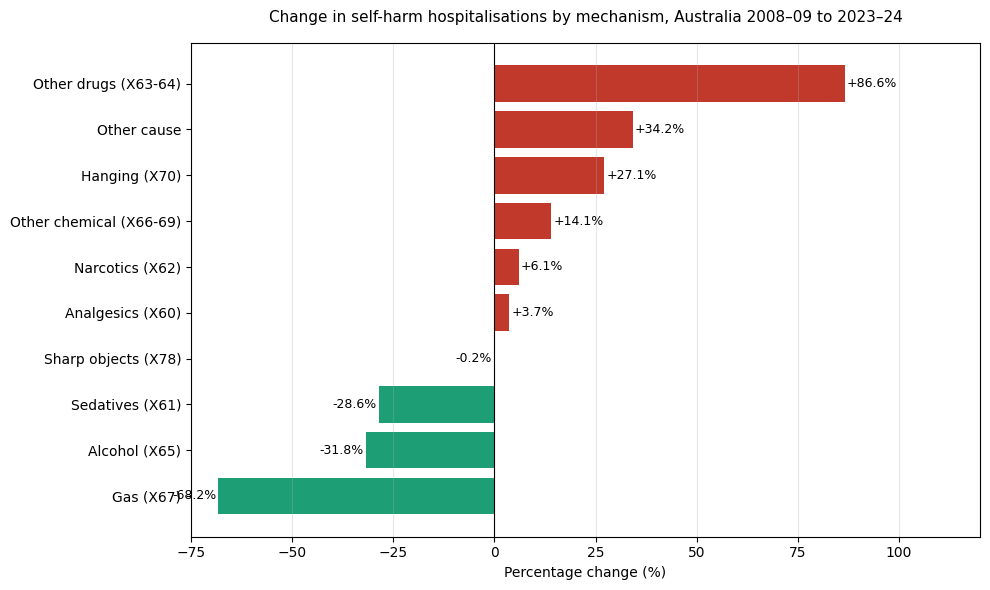

In [13]:
# Calculate % change from first year to last year
df_clean['pct_change'] = ((df_clean['2023–24'] - df_clean['2008–09']) / df_clean['2008–09'] * 100).round(1)
df_clean['short_name'] = df_clean['Mechanism'].map(short_names)

# Sort by % change
change = df_clean[['short_name', 'pct_change']].sort_values('pct_change', ascending=True)

# Colour bars: red for increase, green for decrease
colors = ['#C0392B' if x > 0 else '#1D9E75' for x in change['pct_change']]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(change['short_name'], change['pct_change'], color=colors)

# Add value labels
for bar, val in zip(bars, change['pct_change']):
    x_pos = bar.get_width() + 0.5 if val >= 0 else bar.get_width() - 0.5
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', ha=ha, fontsize=9)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Change in self-harm hospitalisations by mechanism, Australia 2008–09 to 2023–24',
             fontsize=11, pad=15)
ax.set_xlabel('Percentage change (%)')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(-75, 120)

plt.tight_layout()
plt.savefig('chart3_change.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
readme = """# Intentional Self-Harm Hospitalisations in Australia
## Mechanisms of harm — a 16-year trend analysis (2008–09 to 2023–24)

### Data source
Australian Institute of Health and Welfare (AIHW) — National Hospital Morbidity Database

### Key findings

1. **Sedatives remain the leading mechanism** — accounting for 8,723 hospitalisations
   in 2023–24, nearly double the next highest mechanism (analgesics at 4,851).

2. **Overall hospitalisations have declined since a 2016–17 peak** — total separations
   fell from ~33,000 in 2016–17 to ~24,000 in 2023–24, a 27% reduction.

3. **Other drugs (X63-64) have grown sharply** — up +86.6% since 2008–09,
   now the third highest mechanism. This is the most concerning trend in the data.

4. **Gas-related hospitalisations have fallen dramatically** — down -68.2%,
   likely reflecting public health interventions around charcoal burning and
   vehicle exhaust access.

5. **Sharp objects remain stubbornly stable** — virtually unchanged over 16 years
   (-0.2%), suggesting limited progress in this area.

### Charts
- chart1_trends.png — All mechanisms over time (2008–09 to 2023–24)
- chart2_ranking.png — Mechanisms ranked by 2023–24 volume
- chart3_change.png — Percentage change per mechanism over 16 years

### Tools used
- Python (pandas, matplotlib)
- Data source: AIHW NHMD Excel workbook
"""

with open('README.md', 'w') as f:
    f.write(readme)

print("README saved!")

README saved!
